# Стартовый ноутбук

Этот ноутбук показывает минимальный рабочий сценарий:

- создать официальную среду,
- загрузить стартовый класс `Agent`,
- запустить короткий эпизод,
- локально проверить формат отправки.


In [18]:
!cd project && git pull

import importlib
import baseline_dqn_stub

importlib.reload(baseline_dqn_stub)

Already up to date.


<module 'baseline_dqn_stub' from '/kaggle/input/competitions/cu-intro2ai-rl-26/baseline_dqn_stub.py'>

In [7]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

from __future__ import annotations

import argparse
import random
import sys
from collections import deque
from dataclasses import dataclass
from pathlib import Path
from typing import Deque, Dict, List, Tuple
from tqdm.auto import tqdm

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path
import sys

DATA_ROOT = Path("..").resolve()
ENV_DIR = DATA_ROOT / "env"
STARTER_DIR = DATA_ROOT / "starter"

for path in (ENV_DIR, STARTER_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from make_env import make_eval_env
from starter_submission import Agent

env = make_eval_env(seed=0)
observation, info = env.reset(seed=0)
print("Форма наблюдения:", observation.shape)
print("Число возможных действий:", env.action_space.n)


Форма наблюдения: (4, 84, 84)
Число возможных действий: 4


In [11]:
!dir checkpoints

dqn_baseline.pt


In [17]:
from baseline_dqn_stub import Agent

Agent(DATA_ROOT / "checkpoints/dqn_baseline.pt")

FileNotFoundError: Файл весов не найден: /kaggle/checkpoints/dqn_baseline.pt/dqn_breakout.pt. Сначала обучите модель или укажите свои собственные веса.

# Знакомимся со средой

- Поймём что это вообще за среда такая, какие у неё ограничения
- Поймём какие предобработки можно сделать, чтобы упростить работу агента
- Отрисуем видео из игры
- Запустим бейзлайн, посмотрим в чём ошибается моделька

In [67]:
def simulate_game():
    # Симуляция одного эпизода игры, запись кадров для анимации
    frames = []

    observation, info = env.reset(seed=0)
    done = False

    while not done:
        frame = observation[-1]  # последний из четырёх кадров (ч/б)
        frames.append(frame.copy())
        action = np.random.randint(0, 4)

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    # Создаём анимацию matplotlib
    fig, ax = plt.subplots()
    img = ax.imshow(frames[0], cmap='gray', animated=True)
    ax.axis('off')

    def update(i):
        img.set_array(frames[i])
        return (img,)

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=50, blit=True, repeat=False
    )
    plt.close(fig)  # чтобы не дублировать вывод

    return ani

ani = simulate_game()

from IPython.display import HTML
HTML(ani.to_jshtml())

*мысли*

- У нас четыре действия (по сути их даже три): NOOP, LEFT, RIGHT, FIRE (нам нужна только чтобы запустить мячик)
- У меня есть мысли о том, что представлять мир в виде каких-то статистик было бы эффективнее. В крайнем случае, можно было бы обрезать мир Atari и убрать ненужные цифры и стены по бокам.

Убрав лишнюю информацию и в целом сделав предобработку картинки, мы сможем уменьшить число состояний, и сделать нашу Q функцию менее большой.



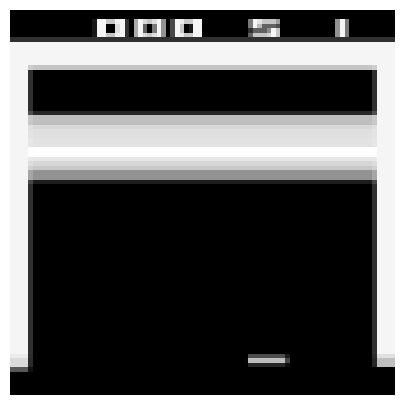

In [68]:
observation, info = env.reset(seed=0)

frame = observation

plt.figure(figsize=(5, 5))
plt.imshow(frame[0], cmap="gray")
plt.axis("off")
plt.show()

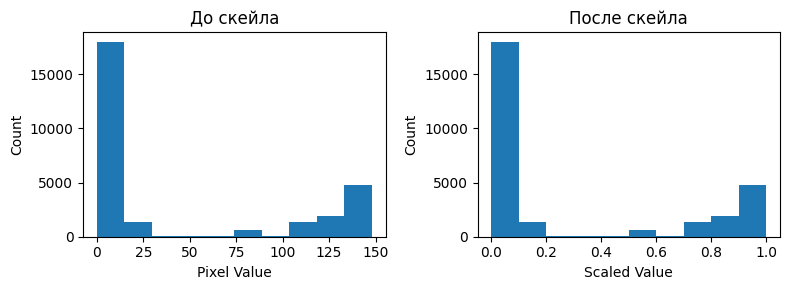

In [69]:
from sklearn.preprocessing import minmax_scale

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.hist(frame.flatten())
plt.title("До скейла")
plt.xlabel("Pixel Value")
plt.ylabel("Count")

frame_scaled = minmax_scale(frame.flatten()).reshape(frame.shape)

plt.subplot(1, 2, 2)
plt.hist(frame_scaled.flatten())
plt.title("После скейла")
plt.xlabel("Scaled Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

y: (12, -2), x: (3, 80)


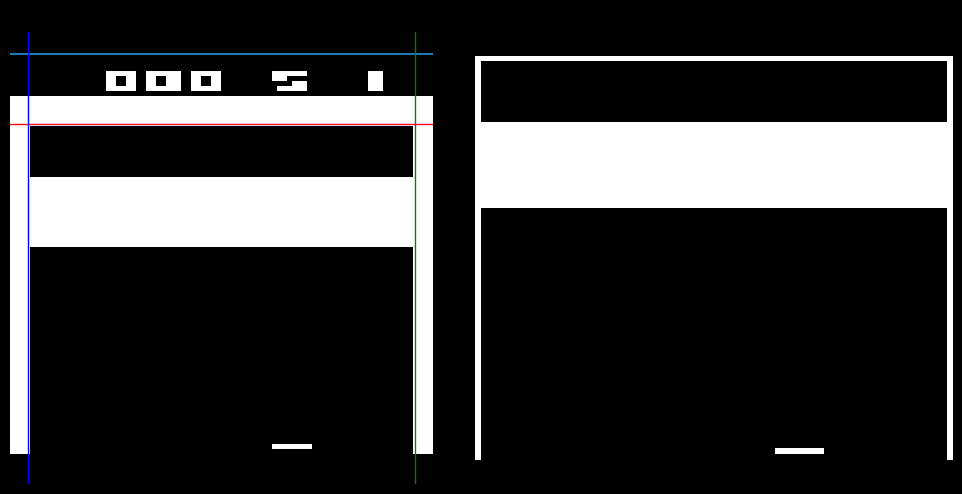

In [70]:
# Предобработки

def crop_frame(frame: np.array) -> np.array:
    return frame[:, 12:78, 3:81]


def preprocess_frame(frame: np.array, crop=True) -> np.array:
    frame_p = minmax_scale(frame.flatten())

    frame_p = frame_p.reshape(frame.shape)
    frame_p = frame_p > 0.45

    if crop:
        frame_p = crop_frame(frame_p)
    
    return frame_p


frame_p_nocrop = preprocess_frame(frame, crop=False)
frame_p_crop = preprocess_frame(frame, crop=True)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.patch.set_facecolor('black')  # устанавливаем черный фон всей фигуры

# для каждого subplot устанавливаем черный фон оси
for ax in axs:
    ax.set_facecolor('black')

axs[0].imshow(frame_p_nocrop[0], cmap="gray")
ys = (12, frame.shape[0] - 6)
xs = (3, frame.shape[1] - 4)

axs[0].axhline(y=frame.shape[0] - 6)
axs[0].axhline(y=12, color='red', linewidth=1)
axs[0].axvline(x=3, color='blue', linewidth=1)
axs[0].axvline(x=frame.shape[1] - 4, color='green', linewidth=1)
axs[0].set_title("preprocess_frame, crop=False")
axs[0].set_axis_off()

print(f"y: {ys}, x: {xs}")

axs[1].imshow(frame_p_crop[0], cmap="gray")
axs[1].set_title("preprocess_frame, crop=True")
axs[1].set_axis_off()

plt.tight_layout()
plt.show()

In [71]:
def simulate_game():
    # Симуляция одного эпизода игры, запись кадров для анимации
    frames = []

    observation, info = env.reset(seed=0)
    done = False

    while not done:
        frame = preprocess_frame(observation)
        frames.append(frame.copy()[0]) # Берём первый из кадров
        action = np.random.randint(0, 4)

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    # Создаём анимацию matplotlib
    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')

    img = ax.imshow(frames[0], cmap='gray', animated=True)

    # Сделать черный фон (можно для наглядности явно нарисовать чёрную рамку)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(5)
        
    ax.axis('off')

    def update(i):
        img.set_array(frames[i])
        return (img,)

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=50, blit=True, repeat=False
    )
    plt.close(fig)  # чтобы не дублировать вывод

    return ani

ani = simulate_game()

from IPython.display import HTML
HTML(ani.to_jshtml())

- Найс, теперь картинка хорошего формата: чёткая, без ничего лишнего, всё по делу.

# Обучение агента

У меня было несколько идей:
1) Обучить бейзлайн DQN (выбить лучший скор)
    - Double DQN (уже в бейзе)
2) Улучшить архитектуру (решить проблему `overestimation bias` как-то более круто)
    - декорреляция семплов
    - Dueling DQN (учим $Q(s, a) = V(s) + A(s, a)$, вместо просто $Q(s, a) = V(s)$)
    - Prioritized DQN (улучшаем то, какие данные сеть видит чаще)
3) Мета-эвристики (если успеется)
    - CEM (Cross-Entropy Method) - храним распределение параметров, семплируем N политик, берём много лучших, сдвигаем распределение параметров ближе к политикам.
    - OpenAI-ES (создаём сеть с параметрами $\theta{}$, создаём дочерних $\theta{} + \sigma{} \epsilon{}_i$, отбираем лучшую через многочисленные запуски. Отбираем лучшую.)

# Обучение модельки

In [72]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
from baseline_dqn_stub import DQNTrainer


basepath = Path("./checkpoints")
basepath.mkdir(parents=True, exist_ok=True)

checkpoint_path = basepath / "dqn_baseline.pt"

trainer = DQNTrainer(train_start = 1000)
history = trainer.train(5_000, checkpoint_path)

Устройство обучения: cpu


Обучаем модельку:   0%|          | 0/5000 [00:00<?, ?it/s]

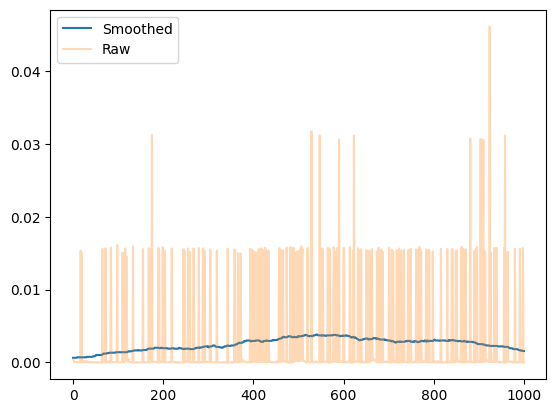

In [ ]:
import numpy as np

losses = history["losses"]

def smooth(y, box_pts=250):
    box = np.ones(box_pts) / box_pts
    return np.convolve(y, box, mode='same')

plt.plot(smooth(losses), label='Smoothed')
plt.plot(losses, alpha=0.3, label='Raw')
plt.legend()

In [85]:
print("updates:", len(history["losses"]))
print("episodes:", len(history["episode_rewards"]))
print("last returns:", history["episode_rewards"][-10:])
print("action_counts:", history["action_counts"])
print("reward_events:", len(history["reward_events"]))
print("life_losses:", history["life_losses"])
print("train_start:", history["train_start"])

updates: 1001
episodes: 30
last returns: [2.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 2.0]
action_counts: [1414, 872, 1099, 1615]
reward_events: 30
life_losses: 122
train_start: 1000


# Evaluation

In [80]:
from tqdm.auto import tqdm

checkpoint_path = Path("checkpoints/dqn_baseline.pt")

agent = Agent(checkpoint_path)
env.reset(seed=0)

actions = []

episode_reward = 0.0
for step in range(128):
    action = agent.act(observation)

    observation, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward

    if terminated or truncated:
        break

    actions.append(action)

env.close()
print("Награда за короткий эпизод:", episode_reward)


Награда за короткий эпизод: 0.0


In [81]:
def simulate_game():
    # Симуляция одного эпизода игры, запись кадров для анимации
    frames = []

    observation, info = env.reset(seed=0)
    agent.reset(seed=0)

    done = False

    step = 0
    while not done:
        frame = observation  # последний из четырёх кадров (ч/б)
        frames.append(frame.copy()[-1])
        action = agent.act(frame)

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        step += 1

        if step == 100:
            break

    # Создаём анимацию matplotlib
    fig, ax = plt.subplots()
    img = ax.imshow(frames[0], cmap='gray', animated=True)
    ax.axis('off')

    def update(i):
        img.set_array(frames[i])
        return (img,)

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=50, blit=True, repeat=False
    )
    plt.close(fig)  # чтобы не дублировать вывод

    return ani

ani = simulate_game()

from IPython.display import HTML
HTML(ani.to_jshtml())

Команда для локальной проверки:

```bash
python competition-data/starter/local_evaluate.py \
  --submission competition-data/starter/starter_submission.py \
  --seeds-file competition-data/public_seeds/local_validation_seeds.json
```
